## 0.データのフィルタリング・クリーニング 関数

### データ読み込みと結合

In [1]:
#csvファイルではなくtxtファイルを読み込むように変更
import pandas as pd
from pathlib import Path

path_1 = Path('../data/raw/trajectories-0400-0415.txt')
path_2 = Path('../data/raw/trajectories-0500-0515.txt')
path_3 = Path('../data/raw/trajectories-0515-0530.txt')

columns = [
    'Vehicle_ID', 'Frame_ID', 'Total_Frames', 'Global_Time', 'Local_X', 'Local_Y',
    'Global_X', 'Global_Y', 'v_Length', 'v_Width', 'v_Class', 'v_Vel', 'v_Acc',
    'Lane_ID', 'Preceding', 'Following', 'Space_Headway', 'Time_Headway'
]

df_1 = pd.read_csv(path_1, sep=r'\s+', header=None, names=columns)
df_2 = pd.read_csv(path_2, sep=r'\s+', header=None, names=columns)
df_3 = pd.read_csv(path_3, sep=r'\s+', header=None, names=columns)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 時間帯の識別列を追加 (id の重複があるため)
df_1['time_period'] = 1  # 4:00-4:15
df_2['time_period'] = 2  # 5:00-5:15
df_3['time_period'] = 3  # 5:15-5:30

# 結合
df = pd.concat([df_1, df_2, df_3], ignore_index=True)

# データの確認
print(df.shape)
df.head()

(4566387, 19)


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceding,Following,Space_Headway,Time_Headway,time_period
0,1,12,884,1113433136100,16.884,48.213,6042842.116,2133117.662,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
1,1,13,884,1113433136200,16.938,49.463,6042842.012,2133118.909,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
2,1,14,884,1113433136300,16.991,50.712,6042841.908,2133120.155,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
3,1,15,884,1113433136400,17.045,51.963,6042841.805,2133121.402,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1
4,1,16,884,1113433136500,17.098,53.213,6042841.701,2133122.649,14.3,6.4,2,12.5,0.0,2,0,0,0.0,0.0,1


In [3]:
# 列名の確認
print(df.columns.tolist())

# データ型の確認
print(df.dtypes)

#欠損値　
print("\n欠損値:")
df.isnull().sum()

# 基本統計量
df.describe()

#v,accはfeet表示であることに注意

['Vehicle_ID', 'Frame_ID', 'Total_Frames', 'Global_Time', 'Local_X', 'Local_Y', 'Global_X', 'Global_Y', 'v_Length', 'v_Width', 'v_Class', 'v_Vel', 'v_Acc', 'Lane_ID', 'Preceding', 'Following', 'Space_Headway', 'Time_Headway', 'time_period']
Vehicle_ID         int64
Frame_ID           int64
Total_Frames       int64
Global_Time        int64
Local_X          float64
Local_Y          float64
Global_X         float64
Global_Y         float64
v_Length         float64
v_Width          float64
v_Class            int64
v_Vel            float64
v_Acc            float64
Lane_ID            int64
Preceding          int64
Following          int64
Space_Headway    float64
Time_Headway     float64
time_period        int64
dtype: object

欠損値:


,Vehicle_ID,Frame_ID,Total_Frames,Global_Time,Local_X,Local_Y,Global_X,Global_Y,v_Length,v_Width,v_Class,v_Vel,v_Acc,Lane_ID,Preceding,Following,Space_Headway,Time_Headway,time_period
count,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06,4.566387e+06
mean,1.588199e+03,5.471980e+03,1.015003e+03,1.113437e+12,3.984736e+01,8.430695e+02,6.042761e+06,2.133909e+06,1.611579e+01,6.852992e+00,2.032801e+00,1.934866e+01,6.237478e-03,3.832722e+00,1.513829e+03,1.523074e+03,5.435219e+01,4.221553e+02,2.107550e+00
std,8.078982e+02,2.661235e+03,4.787489e+02,1.881963e+06,2.107819e+01,4.487661e+02,6.778314e+01,4.447039e+02,7.311574e+00,8.721375e-01,2.005007e-01,1.317379e+01,4.753486e+00,1.680516e+00,8.518476e+02,8.533007e+02,3.725520e+01,1.999911e+03,8.056143e-01
min,1.000000e+00,4.000000e+00,2.030000e+02,1.113433e+12,0.000000e+00,0.000000e+00,6.042587e+06,2.133040e+06,4.900000e+00,2.700000e+00,1.000000e+00,0.000000e+00,-1.120000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,9.540000e+02,3.237000e+03,6.750000e+02,1.113434e+12,1.895600e+01,4.651840e+02,6.042705e+06,2.133535e+06,1.380000e+01,6.300000e+00,2.000000e+00,9.780000e+00,-6.000000e-01,2.000000e+00,8.440000e+02,8.530000e+02,3.300000e+01,2.070000e+00,1.000000e+00
50%,1.642000e+03,5.712000e+03,8.900000e+02,1.113437e+12,4.113200e+01,8.188110e+02,6.042766e+06,2.133885e+06,1.480000e+01,6.900000e+00,2.000000e+00,1.792000e+01,0.000000e+00,4.000000e+00,1.584000e+03,1.592000e+03,4.638000e+01,2.980000e+00,2.000000e+00
75%,2.191000e+03,7.704000e+03,1.358000e+03,1.113438e+12,5.476500e+01,1.228128e+03,6.042818e+06,2.134291e+06,1.590000e+01,7.400000e+00,2.000000e+00,2.649000e+01,6.300000e-01,5.000000e+00,2.156000e+03,2.166000e+03,6.660000e+01,4.620000e+00,3.000000e+00
max,3.366000e+03,1.169100e+04,2.434000e+03,1.113439e+12,9.699600e+01,1.790771e+03,6.042911e+06,2.134845e+06,7.770000e+01,8.500000e+00,3.000000e+00,9.530000e+01,1.120000e+01,7.000000e+00,3.366000e+03,3.366000e+03,1.321550e+03,1.173390e+04,3.000000e+00


In [4]:
# 車種の分布確認
print("車種の分布:")
print(df['v_Class'].value_counts())

# 車線の分布確認
print("\n車線の分布:")
print(df['Lane_ID'].value_counts().sort_index())

# 速度・加速度の基本統計
print("\n速度(feet/s):")
print(df['v_Vel'].describe())

print("\n加速度(feet/s²):")
print(df['v_Acc'].describe())

車種の分布:
v_Class
2    4377903
3     169132
1      19352
Name: count, dtype: int64

車線の分布:
Lane_ID
1    404588
2    830690
3    719832
4    880189
5    785454
6    791237
7    154397
Name: count, dtype: int64

速度(feet/s):
count    4.566387e+06
mean     1.934866e+01
std      1.317379e+01
min      0.000000e+00
25%      9.780000e+00
50%      1.792000e+01
75%      2.649000e+01
max      9.530000e+01
Name: v_Vel, dtype: float64

加速度(feet/s²):
count    4.566387e+06
mean     6.237478e-03
std      4.753486e+00
min     -1.120000e+01
25%     -6.000000e-01
50%      0.000000e+00
75%      6.300000e-01
max      1.120000e+01
Name: v_Acc, dtype: float64


### すべての追従ペアにペアIDを付与　(df_with_pairsを作成)

In [5]:
def give_pair_id(df):
    # ソート
    df = df.sort_values(['Vehicle_ID', 'time_period', 'Global_Time']).copy()
    
    # 条件が途切れるタイミングを検出
    # ① Lane_IDが変わった
    lane_changed = df.groupby(['Vehicle_ID', 'time_period'])['Lane_ID'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )
    
    # ② Precedingが変わった
    preceding_changed = df.groupby(['Vehicle_ID', 'time_period'])['Preceding'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )
    
    # ③ Preceding=0
    preceding_zero = df['Preceding'] == 0
    
    # 条件が途切れるタイミング
    break_point = lane_changed | preceding_changed | preceding_zero
    
    # ペアIDを付与
    df['pair_id'] = break_point.cumsum()
    
    # Preceding=0の行はpair_idをNaNにする
    df.loc[preceding_zero, 'pair_id'] = None
    
    return df

# 実行
df_with_pairs = give_pair_id(df)

# 確認
print(f"総行数: {len(df_with_pairs):,}")
print(f"追従ペア数: {df_with_pairs['pair_id'].nunique():,}")
df_with_pairs[['Vehicle_ID', 'time_period', 'Global_Time', 'Lane_ID', 'Preceding', 'pair_id']].head(20)

総行数: 4,566,387
追従ペア数: 14,800


,Vehicle_ID,time_period,Global_Time,Lane_ID,Preceding,pair_id
0,1,1,1113433136100,2,0,NaN
1,1,1,1113433136200,2,0,NaN
2,1,1,1113433136300,2,0,NaN
3,1,1,1113433136400,2,0,NaN
4,1,1,1113433136500,2,0,NaN
5,1,1,1113433136600,2,0,NaN
6,1,1,1113433136700,2,0,NaN
7,1,1,1113433136800,2,0,NaN
8,1,1,1113433136900,2,0,NaN
9,1,1,1113433137000,2,0,NaN


In [20]:
# 各フラグの確認用
def give_pair_id_debug(df):
    #ソート
    df = df.sort_values(['Vehicle_ID', 'time_period', 'Global_Time']).copy()
    
    # 条件が途切れるタイミングを検出
    # ① Lane_IDが変わった
    lane_changed = df.groupby(['Vehicle_ID', 'time_period'])['Lane_ID'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )

    # ② Precedingが変わった
    preceding_changed = df.groupby(['Vehicle_ID', 'time_period'])['Preceding'].transform(
        lambda x: x != x.shift(fill_value=-1)
    )
    
    # ③ Preceding=0
    preceding_zero = df['Preceding'] == 0
    
    # 条件が途切れるタイミング 
    break_point = lane_changed | preceding_changed | preceding_zero
    
    df['lane_changed'] = lane_changed
    df['preceding_changed'] = preceding_changed
    df['preceding_zero'] = preceding_zero
    df['break_point'] = break_point
    
    # ペアIDを付与
    df['pair_id'] = break_point.cumsum()
    # Preceding=0の行はpair_idをNaNにする
    df.loc[preceding_zero, 'pair_id'] = None

    return df

# デバッグ用実行
df_debug = give_pair_id_debug(df)

# 確認
print(f"総行数: {len(df_debug):,}")
print(f"追従ペア数: {df_debug['pair_id'].nunique():,}")
print("\n最初の20行:")
print(df_debug[['Vehicle_ID', 'time_period', 'Global_Time', 'Lane_ID', 'Preceding', 
                'lane_changed', 'preceding_changed', 'preceding_zero', 'break_point', 'pair_id']].head(20))

総行数: 3,145,725
追従ペア数: 11,294

最初の20行:
    Vehicle_ID  time_period    Global_Time  Lane_ID  Preceding  lane_changed  \
0            1            1  1113433136100        2          0          True   
1            1            1  1113433136200        2          0         False   
2            1            1  1113433136300        2          0         False   
3            1            1  1113433136400        2          0         False   
4            1            1  1113433136500        2          0         False   
5            1            1  1113433136600        2          0         False   
6            1            1  1113433136700        2          0         False   
7            1            1  1113433136800        2          0         False   
8            1            1  1113433136900        2          0         False   
9            1            1  1113433137000        2          0         False   
10           1            1  1113433137100        2          0         False   
11

In [ ]:
# time_period=1のデータを抽出してCSV出力
df_debug_period1 = df_debug[df_debug['time_period'] == 1]

# CSVに出力
df_debug_period1.to_csv('../results/debug_period1.csv', index=False)

print(f"出力行数: {len(df_debug_period1):,}行")
print("出力先: ../results/debug_period1.csv")

出力行数: 1,048,575行
出力先: ../results/debug_period1.csv


### 車線フィルタ

In [7]:
def filter_lane(df, lanes=[2, 3, 4]):
    """
    車線フィルタ
    lanes: 使用する車線のリスト（デフォルト: Lane 2,3,4）
    """
    df_filtered = df[df['Lane_ID'].isin(lanes)]
    
    print(f"フィルタ前: {len(df):,}行")
    print(f"フィルタ後: {len(df_filtered):,}行")
    print(f"除外された行数: {len(df) - len(df_filtered):,}行")
    print(f"\n車線の分布:")
    print(df_filtered['Lane_ID'].value_counts().sort_index())
    
    return df_filtered

In [8]:
# 実行
df_lane_with_pairs = filter_lane(df_with_pairs)

# 追従ペア数の確認
print(f"追従ペア数: {df_lane_with_pairs['pair_id'].nunique():,}")

フィルタ前: 4,566,387行
フィルタ後: 2,430,711行
除外された行数: 2,135,676行

車線の分布:
Lane_ID
2    830690
3    719832
4    880189
Name: count, dtype: int64
追従ペア数: 6,218


### 車種フィルタ

In [9]:
def filter_class(df, classes=[2, 3]):
    """
    車種フィルタ
    classes: 使用する車種のリスト（デフォルト: 2=車, 3=トラック）
    """
    df_filtered = df[df['v_Class'].isin(classes)]
    
    print(f"フィルタ前: {len(df):,}行")
    print(f"フィルタ後: {len(df_filtered):,}行")
    print(f"除外された行数: {len(df) - len(df_filtered):,}行")
    print(f"\n車種の分布:")
    print(df_filtered['v_Class'].value_counts())
    
    return df_filtered


In [10]:
# 実行
df_lane_class_with_pairs = filter_class(df_lane_with_pairs)

# 追従ペア数の確認
print(f"追従ペア数: {df_lane_class_with_pairs['pair_id'].nunique():,}")

フィルタ前: 2,430,711行
フィルタ後: 2,428,817行
除外された行数: 1,894行

車種の分布:
v_Class
2    2313342
3     115475
Name: count, dtype: int64
追従ペア数: 6,133


In [11]:
print(df['v_Class'].value_counts())
print(f"\nLane 2,3,4のバイク数:")
print(len(df[(df['Lane_ID'].isin([2,3,4])) & (df['v_Class'] == 1)]))

v_Class
2    4377903
3     169132
1      19352
Name: count, dtype: int64

Lane 2,3,4のバイク数:
1894


### 追従時間フィルタ

In [12]:
def filter_duration(df, min_duration=60):
    """
    追従時間フィルタ
    min_duration: 最小追従時間（秒）（デフォルト: 60秒）
    """
    # 各ペアの追従時間を計算
    pair_duration = df.groupby('pair_id')['Global_Time'].agg(
        duration=lambda x: (x.max() - x.min()) / 1000  # ミリ秒→秒
    )
    
    # min_duration以上のペアIDを取得
    valid_pair_ids = pair_duration[pair_duration['duration'] >= min_duration].index
    
    # 有効なペアIDの行だけ残す
    df_filtered = df[df['pair_id'].isin(valid_pair_ids)]
    
    print(f"フィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    print(f"除外されたペア数: {df['pair_id'].nunique() - df_filtered['pair_id'].nunique():,}")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    
    return df_filtered

# df_lane_with_pairsに対して実行
df_duration = filter_duration(df_lane_class_with_pairs)

フィルタ前のペア数: 6,133
フィルタ後のペア数: 1,535
除外されたペア数: 4,598

フィルタ前の行数: 2,428,817
フィルタ後の行数: 1,456,062


### 加速度フィルタ
加速度・減速度が1m/s^2 を超えた部分のみを削除する  <br>
NGSIMの単位: feet/s^2<br>
1 feet = 0.3048 m , 1 m = 3.28084 feet<br>
よって、1m/s^2 / 0.3048 = 3.28084 feet /s^2 を超える部分を削除する


In [13]:
def filter_acceleration(df, max_acc=1.0):
    """
    加速度フィルタ
    max_acc: 最大加速度・減速度（m/s²）（デフォルト: 1.0 m/s²）
    """
    # 閾値をfeet/s²に変換
    max_acc_feet = max_acc / 0.3048
    
    # 閾値を超える行を除外
    df_filtered = df[df['v_Acc'].abs() <= max_acc_feet]
    
    print(f"閾値: {max_acc} m/s² = {max_acc_feet:.4f} feet/s²")
    print(f"\nフィルタ前の行数: {len(df):,}")
    print(f"フィルタ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nフィルタ前のペア数: {df['pair_id'].nunique():,}")
    print(f"フィルタ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_acc = filter_acceleration(df_duration)

閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,456,062
フィルタ後の行数: 1,066,466
除外された行数: 389,596

フィルタ前のペア数: 1,535
フィルタ後のペア数: 1,535


### カットオフウィンドウ

In [14]:
print(df_acc['pair_id'].head(10))
print(f"NaNの数: {df_acc['pair_id'].isna().sum():,}")
print(f"ユニークなpair_id数: {df_acc['pair_id'].nunique():,}")

2818495    7823.0
2818496    7823.0
2818497    7823.0
2818498    7823.0
2818499    7823.0
2818502    7823.0
2818503    7823.0
2818504    7823.0
2818507    7823.0
2818511    7823.0
Name: pair_id, dtype: float64
NaNの数: 0
ユニークなpair_id数: 1,535


In [21]:
def apply_cutoff(df, cutoff=10):
    """
    カットオフウィンドウ
    cutoff: カットオフ時間（秒）（デフォルト: 10秒）
    """
    cutoff_ms = cutoff * 1000  # 秒→ミリ秒
    
    # ペアごとの最小・最大時刻を計算
    pair_times = df.groupby('pair_id')['Global_Time'].agg(
        min_time='min',
        max_time='max'
    ).reset_index()
    
    # 元のデータに結合
    df_merged = df.merge(pair_times, on='pair_id')
    
    # カットオフ条件でフィルタリング
    df_filtered = df_merged[
        (df_merged['Global_Time'] >= df_merged['min_time'] + cutoff_ms) &
        (df_merged['Global_Time'] <= df_merged['max_time'] - cutoff_ms)
    ].drop(columns=['min_time', 'max_time'])
    
    print(f"カットオフ前の行数: {len(df):,}")
    print(f"カットオフ後の行数: {len(df_filtered):,}")
    print(f"除外された行数: {len(df) - len(df_filtered):,}")
    print(f"\nカットオフ前のペア数: {df['pair_id'].nunique():,}")
    print(f"カットオフ後のペア数: {df_filtered['pair_id'].nunique():,}")
    
    return df_filtered

# 実行
df_cutoff = apply_cutoff(df_acc)

カットオフ前の行数: 1,067,914
カットオフ後の行数: 863,081
除外された行数: 204,833

カットオフ前のペア数: 1,537
カットオフ後のペア数: 1,537


In [20]:
# ペアごとの追従時間の分布を確認
pair_times = df_acc.groupby('pair_id')['Global_Time'].agg(
    duration=lambda x: (x.max() - x.min()) / 1000
)
print(pair_times['duration'].describe())
print(f"\n20秒以下のペア数: {len(pair_times[pair_times['duration'] <= 20]):,}")

count    1537.000000
mean       94.591672
std        35.634574
min        59.100000
25%        68.500000
50%        80.900000
75%       107.500000
max       216.900000
Name: duration, dtype: float64

20秒以下のペア数: 0


### 確認

In [22]:
# 元データから前方車両の車種を取得
leader_class = df[['Vehicle_ID', 'time_period', 'v_Class']].drop_duplicates()
leader_class = leader_class.rename(columns={'Vehicle_ID': 'Preceding', 'v_Class': 'leader_class'})

# 結合
df_cutoff['ego_class'] = df_cutoff['v_Class']
df_cutoff = df_cutoff.merge(leader_class, on=['Preceding', 'time_period'], how='left')

# 追従タイプを定義
def get_pair_type(ego, leader):
    ego_name = 'Car' if ego == 2 else 'Truck'
    leader_name = 'Car' if leader == 2 else 'Truck'
    return f'{ego_name}-{leader_name}'

df_cutoff['pair_type'] = df_cutoff.apply(
    lambda x: get_pair_type(x['ego_class'], x['leader_class']), axis=1
)

# 出力順番を指定
order = ['Car-Car', 'Car-Truck', 'Truck-Truck', 'Truck-Car']

# ペア数と軌跡数の集計
pairs_count = df_cutoff.groupby(['pair_id', 'pair_type']).size().reset_index()
pairs_summary = pairs_count.groupby('pair_type').size().reindex(order)
trajectory_summary = df_cutoff.groupby('pair_type').size().reindex(order)

print("追従ペア数:")
print(pairs_summary)
print("\n軌跡データ件数:")
print(trajectory_summary)

追従ペア数:
pair_type
Car-Car        1423
Car-Truck        60
Truck-Truck       6
Truck-Car        48
dtype: int64

軌跡データ件数:
pair_type
Car-Car        799536
Car-Truck       34108
Truck-Truck      3773
Truck-Car       25664
dtype: int64


In [24]:
# ② 車線フィルタ
df_lane = filter_lane(df)

# ③ ペアID付与
df_with_pairs = give_pair_id(df_lane)

# ④ 車種フィルタ
df_lane_class = filter_class(df_with_pairs)

# ⑤ 追従時間フィルタ（60秒以上）
df_duration = filter_duration(df_lane_class)

# ⑥ 加速度フィルタ
df_acc = filter_acceleration(df_duration)

# ⑦ カットオフウィンドウ（前後10秒）
df_final = apply_cutoff(df_acc)

# 最終結果の確認
print(f"\n===最終結果===")
print(f"行数: {len(df_final):,}")
print(f"ペア数: {df_final['pair_id'].nunique():,}")

フィルタ前: 4,566,387行
フィルタ後: 2,430,711行
除外された行数: 2,135,676行

車線の分布:
Lane_ID
2    830690
3    719832
4    880189
Name: count, dtype: int64
フィルタ前: 2,430,711行
フィルタ後: 2,428,817行
除外された行数: 1,894行

車種の分布:
v_Class
2    2313342
3     115475
Name: count, dtype: int64
フィルタ前のペア数: 6,110
フィルタ後のペア数: 1,537
除外されたペア数: 4,573

フィルタ前の行数: 2,428,817
フィルタ後の行数: 1,458,102
閾値: 1.0 m/s² = 3.2808 feet/s²

フィルタ前の行数: 1,458,102
フィルタ後の行数: 1,067,914
除外された行数: 390,188

フィルタ前のペア数: 1,537
フィルタ後のペア数: 1,537
カットオフ前の行数: 1,067,914
カットオフ後の行数: 863,081
除外された行数: 204,833

カットオフ前のペア数: 1,537
カットオフ後のペア数: 1,537

===最終結果===
行数: 863,081
ペア数: 1,537


## 実行と確認

In [27]:
print(f"元のデータ:         {len(df):,}行")
print(f"車線・車種フィルタ後: {len(df_lane_class):,}行")
print(f"加速度フィルタ後:    {len(df_acc):,}行")
print(f"60秒フィルタ後:     {len(df_duration):,}行")
print(f"カットオフ後:        {len(df_cutoff):,}行")

元のデータ:         4,566,387行
車線・車種フィルタ後: 2,428,817行
加速度フィルタ後:    1,067,914行
60秒フィルタ後:     1,458,102行
カットオフ後:        863,081行


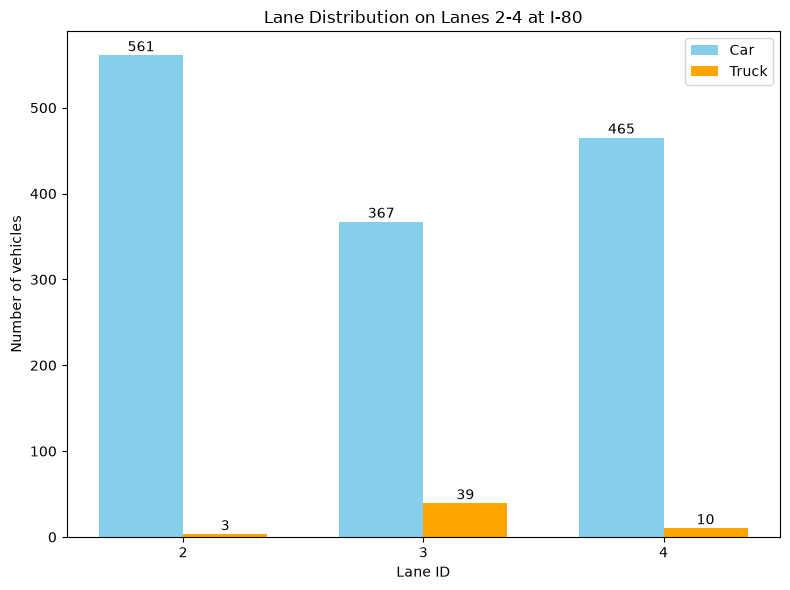

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 解析に使うベースデータを明示的に定義
base_df = df_cutoff.copy()

# 車線ごとの車両数を集計
base_df = base_df.drop_duplicates(subset=['Vehicle_ID', 'time_period', 'Lane_ID'])
lane_class = base_df.groupby(['Lane_ID', 'v_Class'])['Vehicle_ID'].nunique().reset_index()

# 車(v_Class=2)とトラック(v_Class=3)に分ける
cars = lane_class[lane_class['v_Class'] == 2]
trucks = lane_class[lane_class['v_Class'] == 3]

# グラフ描画
x = np.array([2, 3, 4])
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars_car = ax.bar(x - width/2, cars['Vehicle_ID'].values, width, label='Car', color='skyblue')
bars_truck = ax.bar(x + width/2, trucks['Vehicle_ID'].values, width, label='Truck', color='orange')

# 値をバーの上に表示
for bar in bars_car:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

for bar in bars_truck:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(int(bar.get_height())), ha='center', va='bottom')

ax.set_xlabel('Lane ID')
ax.set_ylabel('Number of vehicles')
ax.set_xticks(x)
ax.legend()
ax.set_title('Lane Distribution on Lanes 2-4 at I-80')
plt.tight_layout()
plt.show()